# Model selection 
Select the predicitons tools, scores and settings that best can predicit anti-drug antibodies (ADA) for 218 antibodies.\
Computation of the scores are made in the script "compute_scores" and then imported directly


In [43]:
# load libaries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as sm 
from scipy.stats import pearsonr, spearmanr
import numpy as np

In [2]:
# Load table with all computed scores for all tools
computed_scors_biophi = pd.read_csv("all_predictors_222AB(biophidata).csv")
computed_scors_biophi.head()   

,antibody,ADA_percentage,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC1_pep14_percentile,netMHC1_pep14_immunogenicity_score,netMHC1_pep14_preProcess,netMHC_II_pep12_percentile,netMHC_II_pep12_immunogenicity_score,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.0,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,10.229277,94.757871,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.1,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,9.043928,95.568972,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.5,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,9.043928,96.271372,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.4,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.579673,99.620457,9.130060,96.304235,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.0,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,7.665805,96.583658,0.095804,31.544048,39,0.924883,0.835681


# Scatterplot ADA against all 15 predictors

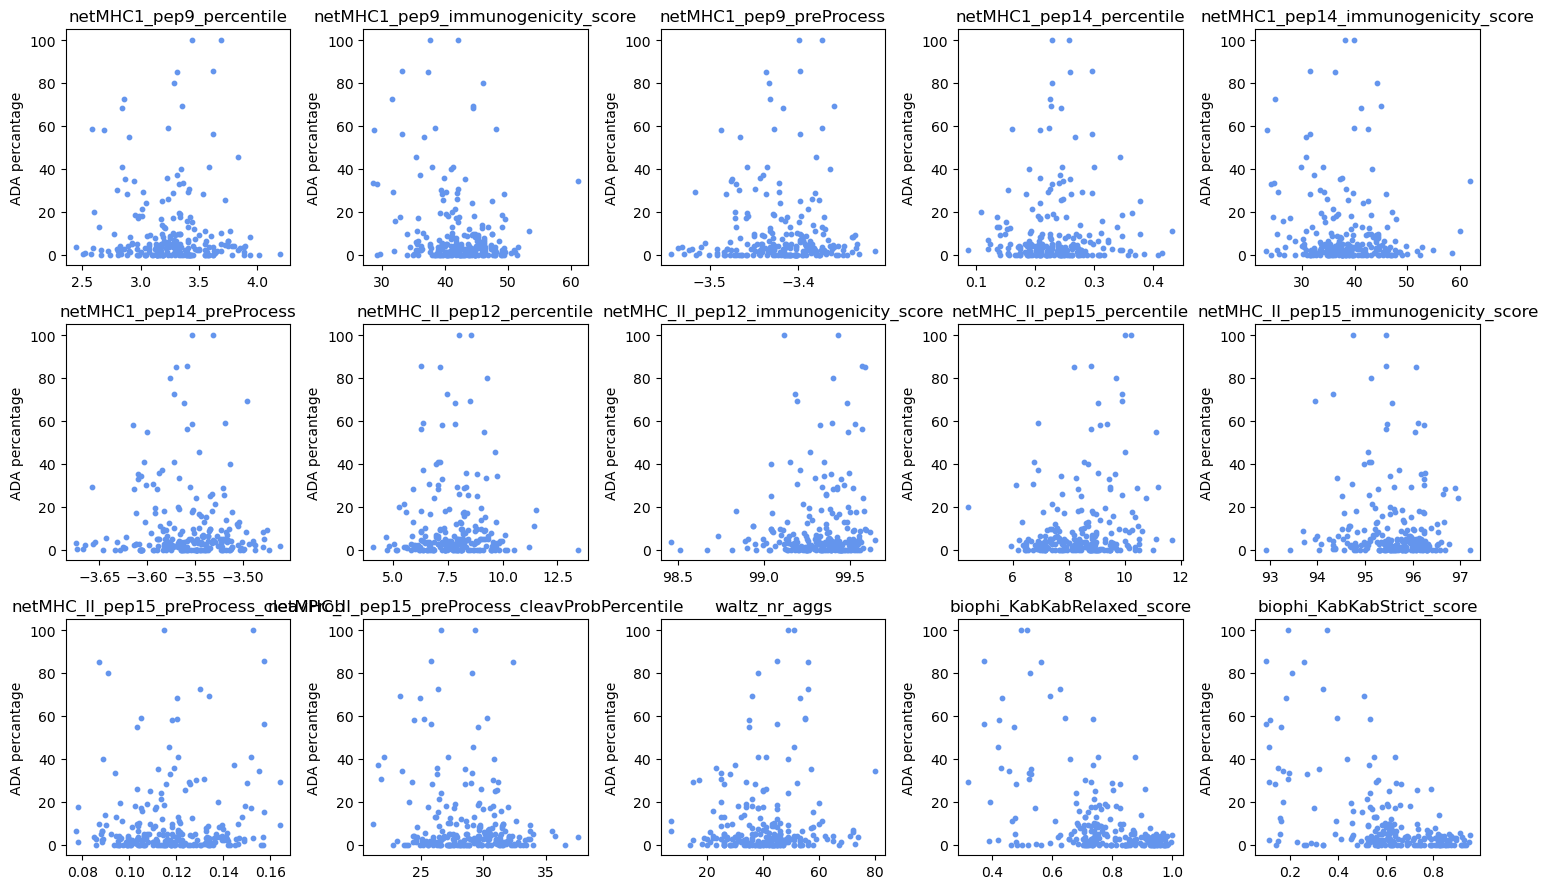

In [3]:
# for loop for all columns, make a scatter plot for each predictor against ADA

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(2, 17):
    ax = axes[i - 2]
    
    y = computed_scors_biophi['ADA_percentage']
    x = computed_scors_biophi.iloc[:, i]
    
    ax.scatter(x, y, s=10, c="cornflowerblue")
    ax.set_title(computed_scors_biophi.columns[i])
    ax.set_ylabel('ADA percantage')

plt.tight_layout()
plt.show()

# Correlation matrix

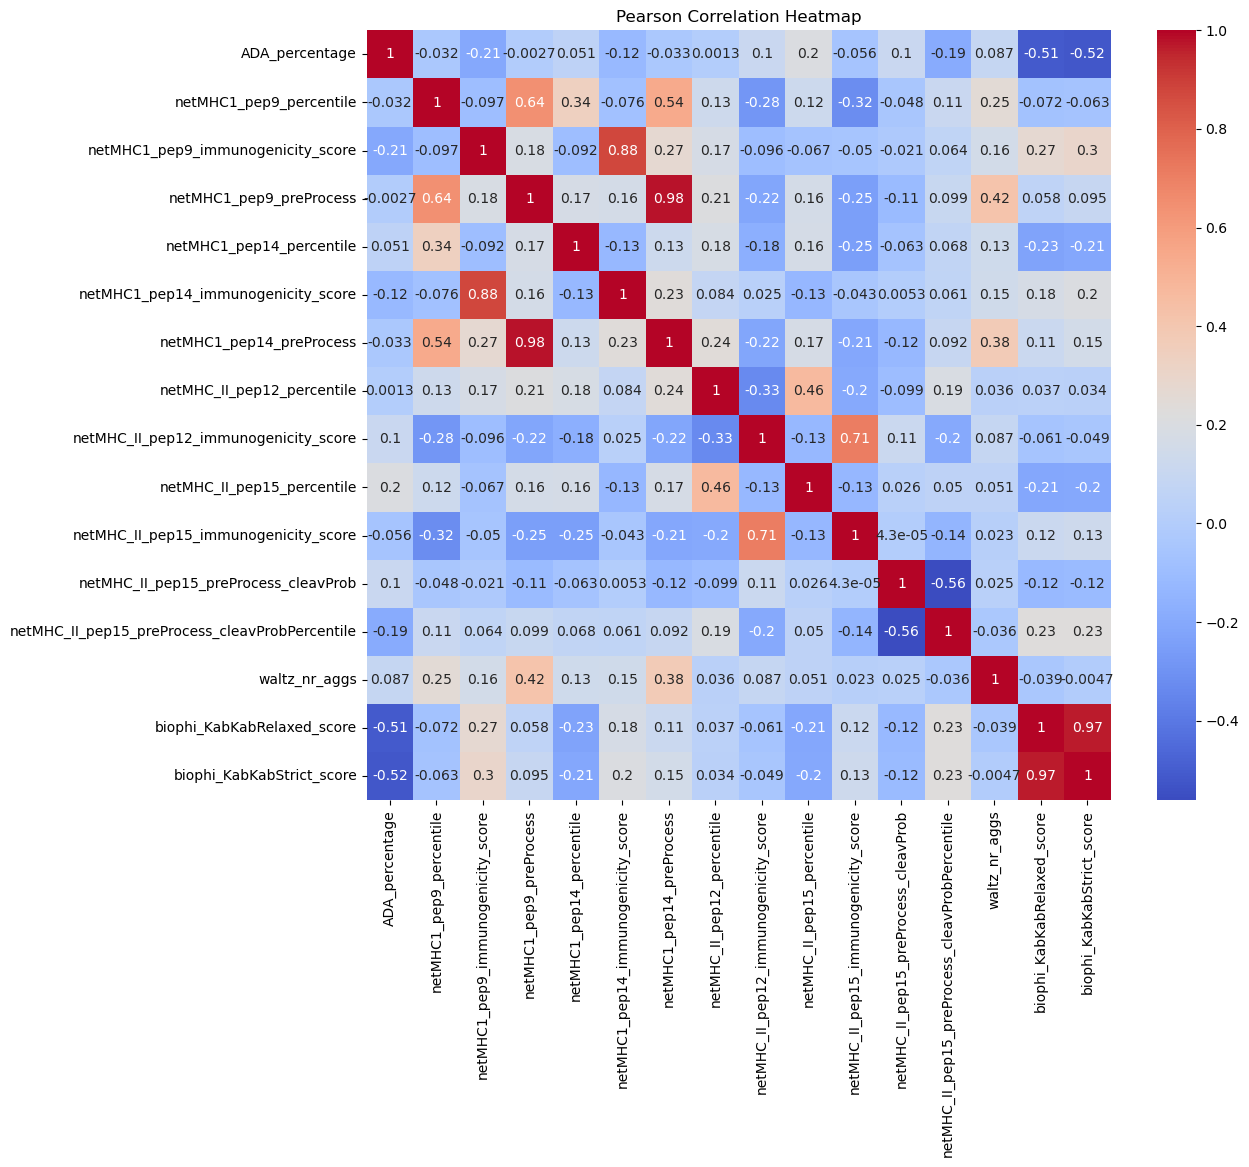

In [4]:
# First create a df without the antibody name and ADA percantage
ADA_corrtest = computed_scors_biophi.drop(columns=['antibody'])
pearson_corr = ADA_corrtest.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

In [5]:
# Compute pearson and spearman, plus their p values for all features against ADA
results = []

for col in computed_scors_biophi.columns[2:19]:  # index 2 to 16 inclusive
    sub_df = computed_scors_biophi[['ADA_percentage', col]]
    
    if len(sub_df) > 1:
        pearson_r, pearson_pval = pearsonr(sub_df['ADA_percentage'], sub_df[col])
        spearman_r, spearman_pval = spearmanr(sub_df['ADA_percentage'], sub_df[col])
        #add sd + cf intervals
        
        
        results.append({
            'variable': col,
            'pearson_r': pearson_r,
            'pearson_pval': pearson_pval,
            'spearman_r': spearman_r,
            'spearman_p': spearman_pval
        })

# Convert to DataFrame
corr_results_df = pd.DataFrame(results)


In [6]:
corr_results_df

,variable,pearson_r,pearson_pval,spearman_r,spearman_p
0,netMHC1_pep9_percentile,-0.031661,6.374047e-01,-0.025075,7.089597e-01
1,netMHC1_pep9_immunogenicity_score,-0.206293,1.911247e-03,-0.131051,5.012662e-02
2,netMHC1_pep9_preProcess,-0.002672,9.682794e-01,0.005162,9.387678e-01
3,netMHC1_pep14_percentile,0.051411,4.438845e-01,0.025680,7.022765e-01
4,netMHC1_pep14_immunogenicity_score,-0.117050,8.045338e-02,-0.095657,1.535997e-01
5,netMHC1_pep14_preProcess,-0.033420,6.188190e-01,0.000269,9.968070e-01
6,netMHC_II_pep12_percentile,0.001259,9.850490e-01,0.046407,4.895408e-01
7,netMHC_II_pep12_immunogenicity_score,0.104449,1.190515e-01,0.052816,4.315114e-01
8,netMHC_II_pep15_percentile,0.204804,2.064478e-03,0.139955,3.632656e-02
9,netMHC_II_pep15_immunogenicity_score,-0.056279,4.018830e-01,-0.072067,2.828368e-01


In [7]:
# print the correlation of the ADA percentage column
pearson_corr['ADA_percentage'].sort_values(ascending=False)

ADA_percentage                                    1.000000
netMHC_II_pep15_percentile                        0.204804
netMHC_II_pep12_immunogenicity_score              0.104449
netMHC_II_pep15_preProcess_cleavProb              0.103738
waltz_nr_aggs                                     0.086635
netMHC1_pep14_percentile                          0.051411
netMHC_II_pep12_percentile                        0.001259
netMHC1_pep9_preProcess                          -0.002672
netMHC1_pep9_percentile                          -0.031661
netMHC1_pep14_preProcess                         -0.033420
netMHC_II_pep15_immunogenicity_score             -0.056279
netMHC1_pep14_immunogenicity_score               -0.117050
netMHC_II_pep15_preProcess_cleavProbPercentile   -0.192310
netMHC1_pep9_immunogenicity_score                -0.206293
biophi_KabKabRelaxed_score                       -0.511477
biophi_KabKabStrict_score                        -0.523883
Name: ADA_percentage, dtype: float64

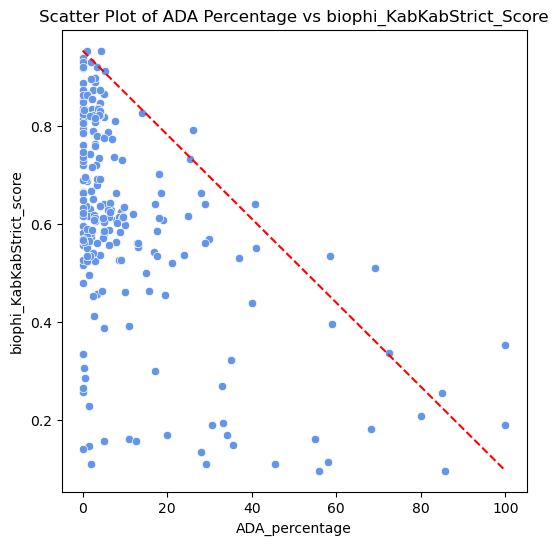

In [8]:


# Scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x='ADA_percentage',
    y='biophi_KabKabStrict_score',
    data=computed_scors_biophi,
    color='cornflowerblue'
)

# Get axis limits from data
x = computed_scors_biophi['ADA_percentage']
y = computed_scors_biophi['biophi_KabKabStrict_score']

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

# Plot perfect negative correlation line
plt.plot([x_min, x_max], [y_max, y_min], linestyle='--', color = "red")


plt.title('Scatter Plot of ADA Percentage vs biophi_KabKabStrict_Score')
plt.show()

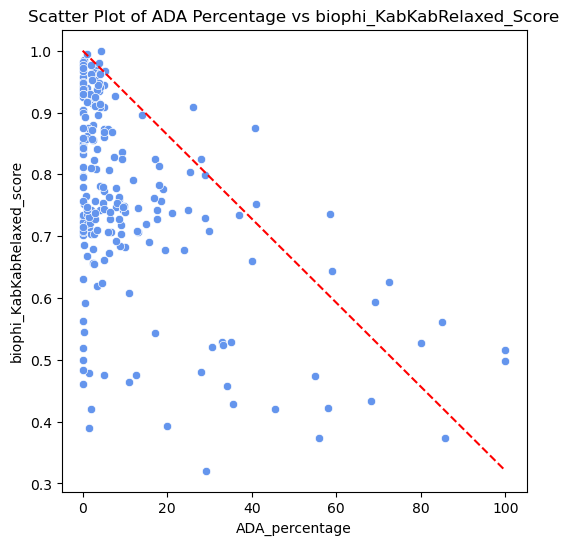

In [9]:
# Scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x='ADA_percentage',
    y='biophi_KabKabRelaxed_score',
    data=computed_scors_biophi,
    color='cornflowerblue'
)

# Get axis limits from data
x = computed_scors_biophi['ADA_percentage']
y = computed_scors_biophi['biophi_KabKabRelaxed_score']

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

# Plot perfect negative correlation line
plt.plot([x_min, x_max], [y_max, y_min], linestyle='--', color = "red")

plt.title('Scatter Plot of ADA Percentage vs biophi_KabKabRelaxed_Score')
plt.show()

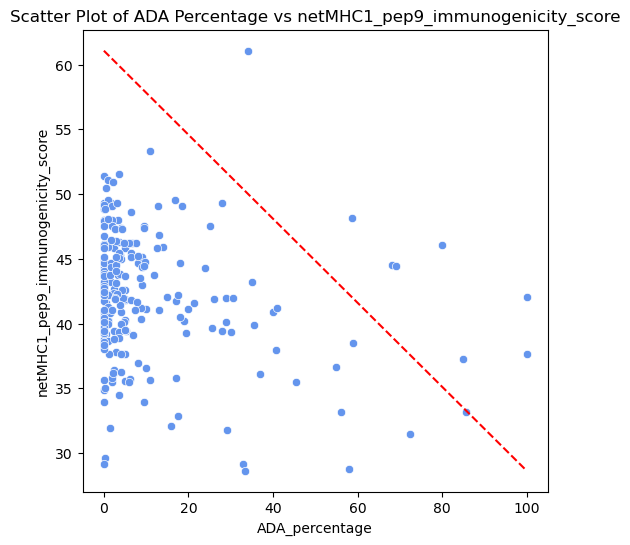

In [10]:
# Scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x='ADA_percentage',
    y='netMHC1_pep9_immunogenicity_score',
    data=computed_scors_biophi,
    color='cornflowerblue'
)

# Get axis limits from data
x = computed_scors_biophi['ADA_percentage']
y = computed_scors_biophi['netMHC1_pep9_immunogenicity_score']

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

# Plot perfect negative correlation line
plt.plot([x_min, x_max], [y_max, y_min], linestyle='--', color = "red")

plt.title('Scatter Plot of ADA Percentage vs netMHC1_pep9_immunogenicity_score')
plt.show()


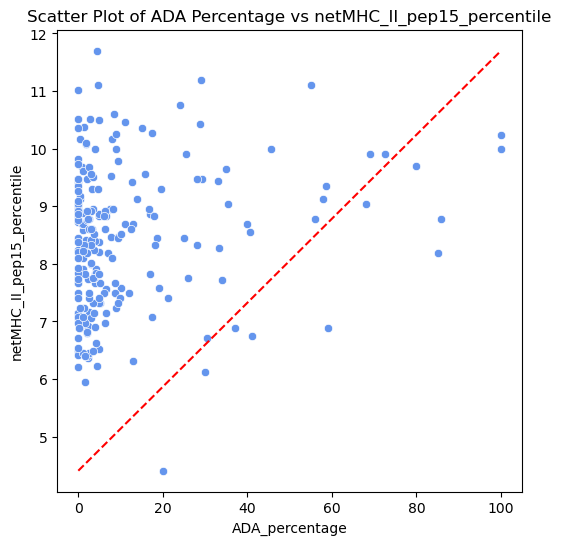

In [11]:
# Scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x='ADA_percentage',
    y='netMHC_II_pep15_percentile',
    data=computed_scors_biophi,
    color='cornflowerblue'
)

# Get axis limits from data
x = computed_scors_biophi['ADA_percentage']
y = computed_scors_biophi['netMHC_II_pep15_percentile']


# Plot perfect negative correlation line
plt.plot([x.min(), x.max()],
         [y.min(), y.max()],
         linestyle='--',
         color='red')


plt.title('Scatter Plot of ADA Percentage vs netMHC_II_pep15_percentile')
plt.show()

# Lasso regression

In [12]:
computed_scors_biophi

,antibody,ADA_percentage,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC1_pep14_percentile,netMHC1_pep14_immunogenicity_score,netMHC1_pep14_preProcess,netMHC_II_pep12_percentile,netMHC_II_pep12_immunogenicity_score,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.00,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,10.229277,94.757871,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.10,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,9.043928,95.568972,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.50,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,9.043928,96.271372,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.40,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.579673,99.620457,9.130060,96.304235,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.00,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,7.665805,96.583658,0.095804,31.544048,39,0.924883,0.835681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,caplacizumab,11.00,3.549383,53.333333,-3.381630,0.193237,60.000000,-3.505279,11.419753,98.935075,10.466989,94.663083,0.121135,32.588182,7,0.608333,0.391667
220,2rs15d,20.00,2.596054,41.121495,-3.471023,0.108932,47.058824,-3.568047,5.291005,99.488019,4.409171,95.527548,0.137821,23.978421,25,0.392523,0.168224
221,gontivimab_alx-0171,34.10,2.944748,61.065574,-3.475876,0.247947,61.924686,-3.606141,9.750567,99.351057,7.716049,95.516623,0.155020,23.435319,80,0.457627,0.169492
222,vobarilizumab,41.00,2.842755,41.228070,-3.435665,0.298954,34.080717,-3.571817,7.160494,99.149196,6.748971,95.134060,0.151941,22.027045,38,0.752667,0.550037


In [13]:
# Add a column to the computed_scors_biophi df called "ADA group", 
# in this column each row is assigned "low", "medium" or "high"
# low is rows with ADA_percentage below 10
# medium is rows wtih ADA_percentage 10 to 30
# high is rows with ADA_percentage above 30
computed_scors_biophi['ADA_group'] = 2 # medium

computed_scors_biophi.loc[computed_scors_biophi['ADA_percentage'] < 10, 'ADA_group'] = 1 # low
computed_scors_biophi.loc[computed_scors_biophi['ADA_percentage'] > 30, 'ADA_group'] = 3 # high

In [14]:
# Number of antibodies with high (3) ADA value
(computed_scors_biophi['ADA_group'] == 3).sum()

np.int64(24)

### All columns/features

In [36]:
# Create feature variables

# Drop anitibody bc its not numeric and shall not be a predictor
# Drop ADA percentage scince its the response, and shall not be included as a predictor
# Drop 1 of 2 features that had a correlation above 0.8. Of the 2 I keep the feature with highest correlation with ADA. 
X_all_features = computed_scors_biophi.drop(columns=[
    'antibody', 
    'ADA_percentage',
    'biophi_KabKabRelaxed_score',
    'netMHC1_pep9_preProcess',
    'netMHC1_pep14_immunogenicity_score',
    'ADA_group'
])
y = computed_scors_biophi['ADA_percentage'] # the response varibale
strata = computed_scors_biophi['ADA_group'] # stratify based on the ADA group (low, medium, high)

seeds = range(100)

r2_scores = []
selected_features_list = []

for seed in seeds:

# split data into training and test set
    X_all_features_train, X_all_features_test, y_all_features_train, y_all_features_test = train_test_split(X_all_features, 
                                                                                                            y, 
                                                                                                            test_size=0.2, 
                                                                                                            random_state=seed,
                                                                                                            stratify=strata)

    model1 = make_pipeline(
        StandardScaler(), # normalize the data
        LassoCV(cv=5,max_iter=10000)  # cross-validation
    )

    model1.fit(X_all_features_train, y_all_features_train)

    # Make and save a prediciton
    y_all_features_pred = model1.predict(X_all_features_test)

    r2 = model1.score(X_all_features_test, y_all_features_test)
    r2_scores.append(r2)

    coef = model1.named_steps['lassocv'].coef_
    selected_features = X_all_features.columns[coef != 0]
    selected_features_list.append(set(selected_features))


In [37]:
mean = np.mean(r2_scores)
std = np.std(r2_scores)
ci95 = 1.96 * std / np.sqrt(len(r2_scores))
print("Mean R²:", np.mean(r2_scores))
print("Std R²:", std)
print(f"95% CI: [{mean - ci95}, {mean + ci95}]")


Mean R²: 0.23751251210861546
Std R²: 0.09458674898739507
95% CI: [0.21897350930708603, 0.2560515149101449]


In [35]:
# count how often each feature is selected
from collections import Counter

feature_counts = Counter()

for feature_set in selected_features_list:
    feature_counts.update(feature_set)

for feature, count in feature_counts.items():
    print(f"{feature}: selected in {count}/100 runs")

netMHC1_pep14_preProcess: selected in 30/100 runs
netMHC1_pep9_immunogenicity_score: selected in 57/100 runs
netMHC1_pep9_percentile: selected in 47/100 runs
netMHC_II_pep12_percentile: selected in 15/100 runs
netMHC_II_pep12_immunogenicity_score: selected in 58/100 runs
netMHC_II_pep15_immunogenicity_score: selected in 25/100 runs
biophi_KabKabStrict_score: selected in 100/100 runs
netMHC_II_pep15_percentile: selected in 85/100 runs
netMHC_II_pep15_preProcess_cleavProbPercentile: selected in 63/100 runs
waltz_nr_aggs: selected in 60/100 runs
netMHC1_pep14_percentile: selected in 34/100 runs
netMHC_II_pep15_preProcess_cleavProb: selected in 23/100 runs


# Simple regression with biophi strict
The mean R^2 is lower than the pearson correlation between biophi Strict squared (0.52^2 = 0.27, and R^2 is 0.23). THese are kinda comparable. But do a normal regression to test this.


### Without BioPhi
The BioPhi tool can't take minibinders as input. Therefore it is of intereset to understand wich are the best explainatory features, when biophi is excluded. 

In [39]:
# Lasso regression without the biophi score, since the biophi tool does not accept minibinders as input
X_no_biophi = computed_scors_biophi.drop(columns=['antibody', 'ADA_percentage', 'ADA_group',
                                                  'netMHC1_pep9_preProcess','netMHC1_pep14_immunogenicity_score', 
                                                  'biophi_KabKabStrict_score', 'biophi_KabKabRelaxed_score']) 
y = computed_scors_biophi['ADA_percentage'] # the response varibale

strata = computed_scors_biophi['ADA_group'] # stratify based on the ADA group (low, medium, high)

seeds = range(100)

r2_scores_no_biophi = []
selected_features_list_no_biophi = []

for seed in seeds:

    # split data into training and test set
    X_no_biophi_train, X_no_biophi_test, y_no_biophi_train, y_no_biophi_test = train_test_split(X_no_biophi, 
                                                                                                y, 
                                                                                                test_size=0.2, 
                                                                                                random_state=seed, 
                                                                                                stratify=strata)

    model2 = make_pipeline(
        StandardScaler(), # normalize the data
        LassoCV(cv=5,max_iter=10000)  # cross-validation
    )

    model2.fit(X_no_biophi_train, y_no_biophi_train)

    # Make and save a prediciton
    y_all_features_pred = model2.predict(X_no_biophi_test)

    r2 = model2.score(X_no_biophi_test, y_no_biophi_test)
    r2_scores_no_biophi.append(r2)

    coef = model2.named_steps['lassocv'].coef_
    selected_features = X_no_biophi.columns[coef != 0]
    selected_features_list_no_biophi.append(set(selected_features))

In [40]:
mean = np.mean(r2_scores_no_biophi)
std = np.std(r2_scores_no_biophi)
ci95 = 1.96 * std / np.sqrt(len(r2_scores_no_biophi))
print("Mean R²:", mean)
print("Std R²:", std)
print(f"95% CI: [{mean - ci95}, {mean + ci95}]")

Mean R²: 0.058761485248941356
Std R²: 0.07575271989865993
95% CI: [0.04391395214880401, 0.07360901834907871]


In [41]:
# count how often each feature is selected
from collections import Counter

feature_counts_no_biophi = Counter()

for feature_set in selected_features_list_no_biophi:
    feature_counts_no_biophi.update(feature_set)

for feature, count in feature_counts_no_biophi.items():
    print(f"{feature}: selected in {count}/100 runs")

netMHC1_pep9_immunogenicity_score: selected in 100/100 runs
netMHC1_pep9_percentile: selected in 77/100 runs
netMHC_II_pep12_immunogenicity_score: selected in 92/100 runs
netMHC_II_pep15_immunogenicity_score: selected in 90/100 runs
netMHC_II_pep15_percentile: selected in 100/100 runs
netMHC_II_pep15_preProcess_cleavProbPercentile: selected in 100/100 runs
waltz_nr_aggs: selected in 87/100 runs
netMHC1_pep14_percentile: selected in 27/100 runs
netMHC_II_pep15_preProcess_cleavProb: selected in 37/100 runs
netMHC1_pep14_preProcess: selected in 24/100 runs
netMHC_II_pep12_percentile: selected in 23/100 runs


Features selected 100% of the runs\
netMHC1_pep9_immunogenicity_score\
netMHC_II_pep15_percentile\
netMHC_II_pep15_preProcess_cleavProbPercentile\
\
Features selected more than 50% of times\
etMHC_II_pep12_immunogenicity_score 92%\
netMHC_II_pep15_immunogenicity_score 90%\
waltz_nr_aggs 87%\
netMHC1_pep9_percentile\
\
Features selected less than 50% of runs\
netMHC1_pep14_percentile\
netMHC_II_pep15_preProcess_cleavProb\
netMHC1_pep14_preProcess\
netMHC_II_pep12_percentile


The results from the lasso regression wihtout biophi as a feature is unsatisfactory. Therefore other types of models are tested. 

# Ridge regression
Ridge is also suppose to handle correlated features better. And the features included here are absolutly correlated.

In [47]:
# Ridge regression

X_no_biophi = computed_scors_biophi.drop(columns=['antibody', 'ADA_percentage', 'ADA_group',
                                                  'netMHC1_pep9_preProcess','netMHC1_pep14_immunogenicity_score', 
                                                  'biophi_KabKabStrict_score', 'biophi_KabKabRelaxed_score',
                                                  'netMHC1_pep14_percentile','netMHC_II_pep15_preProcess_cleavProb', # remove features that was rarely selected in the lasso regression
                                                  'netMHC1_pep14_preProcess','netMHC_II_pep12_percentile']) 
y = computed_scors_biophi['ADA_percentage'] # the response varibale

strata = computed_scors_biophi['ADA_group'] # stratify based on the ADA group (low, medium, high)

seeds = range(100)

r2_scores_no_biophi = []
selected_features_list_no_biophi = []

for seed in seeds:

    # split data into training and test set
    X_no_biophi_train, X_no_biophi_test, y_no_biophi_train, y_no_biophi_test = train_test_split(X_no_biophi, 
                                                                                                y, 
                                                                                                test_size=0.2, 
                                                                                                random_state=seed, 
                                                                                                stratify=strata)

    model3 = make_pipeline(
        StandardScaler(), # normalize the data
        RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
  # cross-validation
    )

    model3.fit(X_no_biophi_train, y_no_biophi_train)

    # Make and save a prediciton
    y_all_features_pred = model3.predict(X_no_biophi_test)

    r2 = model3.score(X_no_biophi_test, y_no_biophi_test)
    r2_scores_no_biophi.append(r2)

    coef = model3.named_steps['ridgecv'].coef_

    # rank features by absolute importance
    feature_importance = sorted(
        zip(X_no_biophi.columns, coef),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    selected_features_list_no_biophi.append(feature_importance)

    mean = np.mean(r2_scores_no_biophi)
std = np.std(r2_scores_no_biophi)
ci95 = 1.96 * std / np.sqrt(len(r2_scores_no_biophi))
print("Mean R²:", mean)
print("Std R²:", std)
print(f"95% CI: [{mean - ci95}, {mean + ci95}]")


Mean R²: 0.07976177809873407
Std R²: 0.06280033147830874
95% CI: [0.06745291312898555, 0.09207064306848259]


In [46]:
from collections import defaultdict

feature_weights = defaultdict(list)

for run in selected_features_list_no_biophi:
    for feature, coef in run:
        feature_weights[feature].append(abs(coef))

# average importance
avg_importance = {
    feature: np.mean(values)
    for feature, values in feature_weights.items()
}

# sort
sorted_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)

for f, v in sorted_features:
    print(f"{f}: {v}")

netMHC1_pep9_immunogenicity_score: 2.5678205727652728
netMHC_II_pep15_percentile: 2.533967842552302
netMHC_II_pep15_preProcess_cleavProbPercentile: 2.176188918128717
netMHC_II_pep15_immunogenicity_score: 2.0915199271698843
netMHC_II_pep12_immunogenicity_score: 1.8730416730448658
waltz_nr_aggs: 1.3223345344479205
netMHC1_pep9_percentile: 1.002589464194128


The same features get the absolute strongest signal in the ridge regression as in the lasso regression. These features are netMHC1_pep9_immunogenicity_score, netMHC_II_pep15_percentile, netMHC_II_pep15_preProcess_cleavProbPercentile.\
Also netMHC_II_pep15_immunogenicity_score has a high score here.\
Just like in the lasso regression the features: netMHC_II_pep12_immunogenicity_score,  waltz_nr_aggs and netMHC1_pep9_percentile have weaker influence on the model. 

In [48]:
# Ridge with only the top 3 features 

features__top3 = [
    'netMHC1_pep9_immunogenicity_score',
    'netMHC_II_pep15_percentile',
    'netMHC_II_pep15_preProcess_cleavProbPercentile'
]

X_top3= computed_scors_biophi[features__top3]
y = computed_scors_biophi['ADA_percentage']
strata = computed_scors_biophi['ADA_group']

seeds = range(100)

r2_scores_A = []
coef_runs_A = []

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X_top3, y,
        test_size=0.2,
        random_state=seed,
        stratify=strata
    )

    model4 = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
    )

    model4.fit(X_train, y_train)
    r2_scores_A.append(model4.score(X_test, y_test))

    coef_runs_A.append(model4.named_steps['ridgecv'].coef_)


std = np.std(r2_scores_no_biophi)
ci95 = 1.96 * std / np.sqrt(len(r2_scores_no_biophi))
print("Mean R²:", mean)
print("Std R²:", std)
print(f"95% CI: [{mean - ci95}, {mean + ci95}]")

Mean R²: 0.07976177809873407
Std R²: 0.06280033147830874
95% CI: [0.06745291312898555, 0.09207064306848259]


# Manual model selection
For making a therapeutic profiler it is inconvinient to have as many features as are included here every time a prediction need to be made. Therefore, based on the selected features from the Lasso regressio, here I will try to make as good model as possible with as convinient features as possible. Convinient here meaning that using different settings also results in more manual work and will try to be avioded. 

# Visualization of results

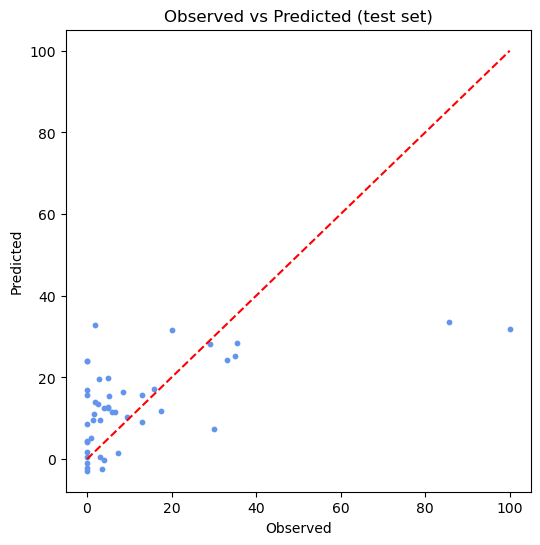

In [19]:
# Visualizaton model 1

plt.figure(figsize=(6,6))
plt.scatter(y_all_features_test, y_all_features_pred, s=10, c="cornflowerblue")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red', linestyle='--')

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted (test set)")
plt.show()

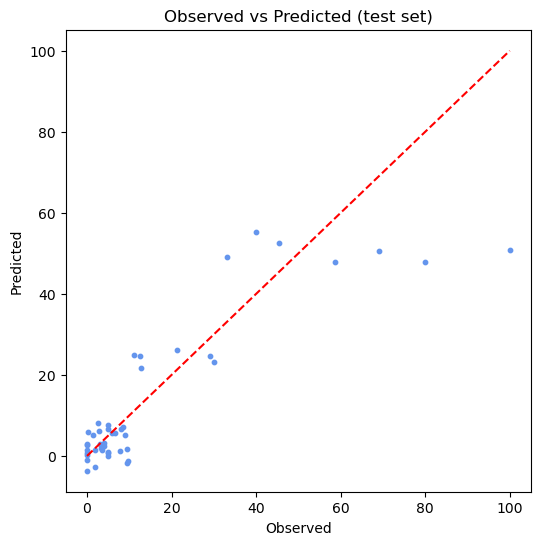

In [20]:
# Visualizaton model 2

plt.figure(figsize=(6,6))
plt.scatter(y_no_biophi_test, y_no_biophi_pred, s=10, c="cornflowerblue")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red', linestyle='--')

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted (test set)")
plt.show()

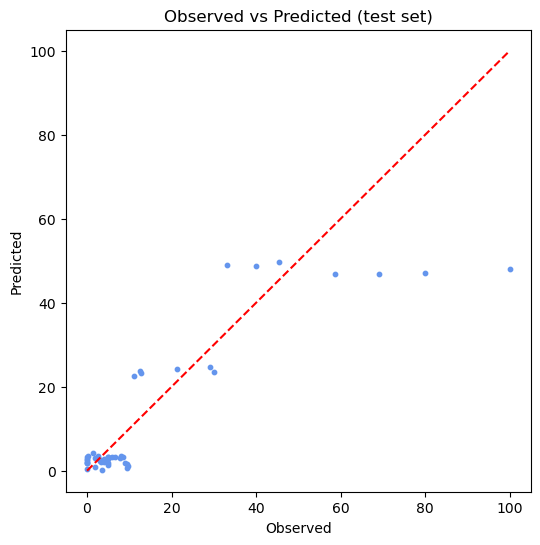

In [21]:
# Visualizaton model 3

plt.figure(figsize=(6,6))
plt.scatter(y_only_default_settings_test, y_only_default_settings_pred, s=10, c="cornflowerblue")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red', linestyle='--')

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted (test set)")
plt.show()

# Manual model selection, regression
